In [121]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import networkx as nx


In [314]:
def generate_adjency_matrix(n_nodes, connectivity_p, epsilon):
    graph = nx.fast_gnp_random_graph(n_nodes, connectivity_p)
    adjency_matrix = nx.to_numpy_array(graph) * epsilon

    for i in range(n_nodes):
        adjency_matrix[i, i] = 1
    return adjency_matrix


graph = generate_adjency_matrix(4, 0.2, 0.1)
print(graph)

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


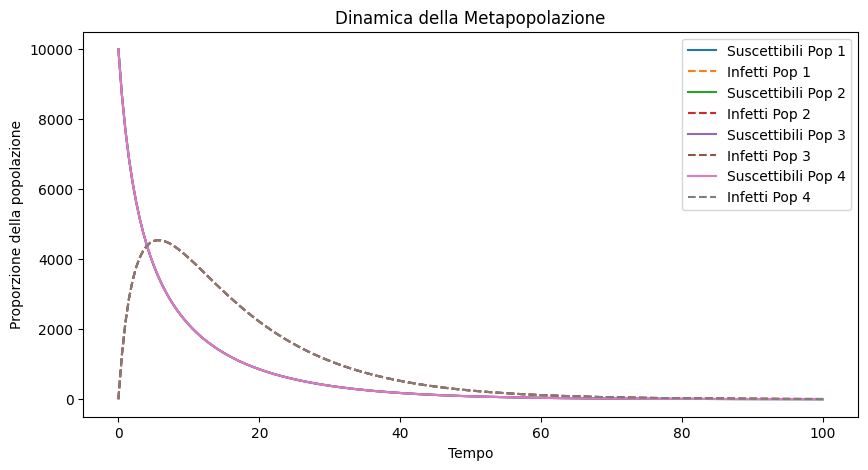

In [628]:
# Numero di sottopopolazioni
num_pops = 4

# Parametri
v = [0, 0, 0, 0]    # Tasso di nascita
mu = [0, 0, 0, 0]   # Tasso di mortalità
gamma = [0.1, 0.1, 0.1, 0.1]   # Tasso di guarigione
beta = [0.3, 0.3, 0.3, 0.3]   # Tasso di trasmissione locale

rho = np.array([[1.0, 0.02, 0.02],
                [0.05, 1.0, 0.03],
                [0.02, 0.03, 1.0]])

rho0 = np.array([[1, 0.01, 0.0001, 0],
                 [0, 1, 0, 0],  
                 [0, 0, 1, 0], 
                 [0, 0, 0, 1]])

eps = 0.0001
rho_chain = np.array([[1, eps, 0, 0],
                 [eps, 1, eps, 0],
                 [0, eps, 1, eps],
                 [0, 0, eps, 1]])

# Condizioni iniziali
X0 = [10000-1, 10000, 10000, 10000]
Y0 = [1, 0, 0, 0]
R0 = [0, 0, 0, 0]
y0 = np.array(X0 + Y0)

def metapopulation_model(t, y):
    dXdt = np.zeros(num_pops)
    dYdt = np.zeros(num_pops)

    X = y[:num_pops]
    Y = y[num_pops:]
    N = X + Y

    for i in range(num_pops):
        # Nuova definizione di lambda_i
        lambda_i = beta[i] * sum(rho_chain[i, j] * (X[j] / N[i]) for j in range(num_pops))
        
        dXdt[i] = v[i]*N[i] - lambda_i* X[i] - mu[i] * X[i]
        dYdt[i] = lambda_i * X[i] - gamma[i] * Y[i] - mu[i] * Y[i]

    return np.concatenate([dXdt, dYdt])

# Simulazione nel tempo
t_span = (0, 100)
t_eval = np.linspace(*t_span, 200)
sol = solve_ivp(metapopulation_model, t_span, y0, t_eval=t_eval)

# Grafico dei risultati
plt.figure(figsize=(10, 5))
for i in range(num_pops):
    plt.plot(sol.t, sol.y[i], label=f"Suscettibili Pop {i+1}")
    plt.plot(sol.t, sol.y[num_pops + i], '--', label=f"Infetti Pop {i+1}")

plt.xlabel("Tempo")
plt.ylabel("Proporzione della popolazione")
plt.legend()
plt.title("Dinamica della Metapopolazione")
plt.show()

In [626]:
def gillespie_metapopulation(S, I, R, beta, gamma, rho, Tmax):
    n = len(S)
    t = 0
    time = [t]
    results = [np.hstack((S, I, R))]
    
    while t < Tmax:
        # Compute rates
        rate_infect = beta * S * I  # Infection within populations
        rate_recover = gamma * I    # Recovery within populations
        rate_transmit = rho * beta * np.outer(I, S)  # Transmission between populations
        
        rates = np.hstack((rate_infect, rate_recover, rate_transmit.flatten()))
        total_rate = np.sum(rates)
        
        if total_rate == 0:
            break  # No more events possible
        
        # Time step
        dt = np.random.exponential(1 / total_rate)
        t += dt
        
        # Choose which event happens
        event = np.random.choice(len(rates), p=rates / total_rate)
        
        # Apply event
        if event < n:  # Infection within population
            pop = event
            S[pop] -= 1
            I[pop] += 1
        elif event < 2 * n:  # Recovery within population
            pop = event - n
            I[pop] -= 1
            R[pop] += 1
        else:  # Transmission between populations
            event -= 2 * n
            j = event % n
            if S[j] > 0:
                S[j] -= 1
                I[j] += 1
        
        time.append(t)
        results.append(np.hstack((S, I, R)))
    
    return np.array(time), np.array(results)

In [627]:
# Number of populations
n = 4
S = np.full(n, 5000)
I = np.zeros(n)
R = np.zeros(n)
I[0] = 1  # Initial infection in the first population

beta = np.full(n, 0.3)  # Transmission rates

rho = np.full((n, n), 0.01)  # Coupling between populations
np.fill_diagonal(rho, 1)


rho_single_pop = np.full(n, 1)

rho_islands = np.eye(n)

eps = 0.0001
rho_chain = np.array([[1, eps, 0, 0],
                 [eps, 1, eps, 0],
                 [0, eps, 1, eps],
                 [0, 0, eps, 1]])

rho1 = np.array([[1, 0.1, 0.1, 0.1],
                 [0.1, 1, 0.1, 0.1],
                 [0.1, 0.1, 1, 0.1],
                 [0.1, 0.1, 0.1, 1]])

rho2 = np.array([[1, 0, 0.1, 0.1],
                 [0, 1, 0.1, 0],
                 [0.1, 0.1, 1, 0.1],
                 [0.1, 0, 0.1, 1]])

rho = generate_adjency_matrix(n, 0.5, 0.1)
for i in range(n): rho[i, i] = 1

gamma = 0.01  # Recovery rate
Tmax = 100  # Max time

# Run simulation
time, results = gillespie_metapopulation(S, I, R, beta, gamma, rho_chain, Tmax)
# Plot results
plt.figure(figsize=(10,5))
for i in range(n):
    plt.plot(time, results[:,n + i], label=f'Infected Pop {i+1}')
    plt.plot(time, results[:,2*n + i], '--', label=f'Recovered Pop {i+1}')
    plt.plot(time, results[:,i], ':', label=f'Susceptible Pop {i+1}')
    
plt.xlabel('Time')
plt.ylabel('Number of Infected')
plt.legend()
plt.title('Stochastic Epidemic Simulation in Multiple Metapopulations')
plt.show()



C:\Users\Lorenzo\AppData\Local\Temp\ipykernel_11400\3256474890.py:9: RuntimeWarning: divide by zero encountered in divide
  rate_infect = (beta/S) * S * I  # Infection within populations
C:\Users\Lorenzo\AppData\Local\Temp\ipykernel_11400\3256474890.py:9: RuntimeWarning: invalid value encountered in multiply
  rate_infect = (beta/S) * S * I  # Infection within populations


ValueError: probabilities contain NaN

---

# 2 Populations experiment

For a metapopulation with just 2 populations we examine the effect of coupling ρ<sub>21</sub> on the dynamics of the epidemic in population 2.


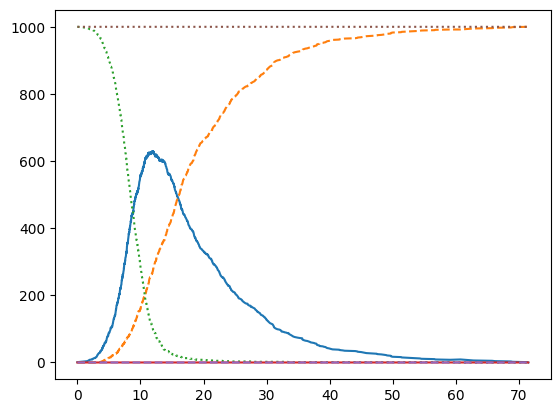

In [604]:
# Definition of the parameters
n = 2

S = np.full(n, 1000)
I = np.zeros(n)
R = np.zeros(n)

I[0] = 1

rho_range = np.linspace(1e-6, 1, 100)

rho_2_pop = np.array([[1, 0],
                      [0.1, 1]])
gamma = 0.1
beta = np.full(n, 0.3571/1000)


Tmax = 100

time, results = gillespie_metapopulation(S, I, R, beta, gamma, rho_2_pop, Tmax)

for i in range(n):
    plt.plot(time, results[:,n + i], label=f'Infected Pop {i+1}')
    plt.plot(time, results[:,2*n + i], '--', label=f'Recovered Pop {i+1}')
    plt.plot(time, results[:,i], ':', label=f'Susceptible Pop {i+1}')
